# Speaking to dead characters in Flavian Epic

In [1]:
### Prereqs

# DICES client
!pip install -qqq git+https://github.com/cwf2/dices-client

# Waffle chart package
!pip install -qqq pywaffle

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 67.5 MB/s eta 0:00:00


### Import statements

In [2]:
from dicesapi import DicesAPI
from pywaffle import Waffle
import matplotlib.pyplot as plt

## Collect data
### Download all speeches

In [3]:
# connect to api
api = DicesAPI(logdetail=0)

# download all speeches
speeches = sorted(
            api.getSpeeches(author_name="Valerius Flaccus")
            + api.getSpeeches(author_name="Statius")
            + api.getSpeeches(author_name="Silius")
    )

In [4]:
silius_italicus_speeches = [s for s in speeches if s.author.name == 'Silius']

print("First five speeches by Silius Italicus:")
for i, speech in enumerate(silius_italicus_speeches[:5]):
    print(f"{i+1}. {speech.work.title} {speech.l_range}: {speech.getSpkrString()} -> {speech.getAddrString()}")

First five speeches by Silius Italicus:
1. Punica 1.42-1.54: Juno -> river Aufidus, river Ticinus
2. Punica 1.106-1.119: Hamilcar -> Hannibal, dead Dido
3. Punica 1.125-1.137: Massylian priestess -> Hamilcar
4. Punica 1.340-1.344: Hannibal -> Carthaginians
5. Punica 1.384-1.386: Murrus -> Aradus


In [5]:
print('Authors of retrieved speeches:')
authors_in_speeches = {s.author.name for s in speeches}
for author_name in sorted(list(authors_in_speeches)):
    print(f"- {author_name}")

Authors of retrieved speeches:
- Silius
- Statius
- Valerius Flaccus


### Sort by changed state of speaker, addressee

Create a dictionary with every combination of speaker/addressee state. Go through speeches one by one, and add to the list for each speaker/addressee combo.

**NB** Speeches can be added to the count for more than one category, for example if one addressee is dead and another is alive. But each speech can only be added to each category once (`set.add()` won't accept duplicate entries).

In [6]:
# create a dictionary where key is spkr-addr state combo, values are sets
index = {
    "alive-alive": set(),
    "alive-dead": set(),
    "alive-divine": set(),
    "dead-alive": set(),
    "dead-dead": set(),
    "dead-divine": set(),
    "divine-alive": set(),
    "divine-dead": set(),
    "divine-divine": set(),
}

# iterate over speeches
for s in speeches:
    # Determine the states of all speakers in the current speech
    speaker_states_for_this_speech = set()
    for spkr in s.spkr:
        if spkr.being == "divine": # Check divine status first
            speaker_states_for_this_speech.add("divine")
        elif spkr._attributes["changed"] == "death": # Then check death status
            speaker_states_for_this_speech.add("dead")
        else: # Otherwise, it's alive
            speaker_states_for_this_speech.add("alive")

    # Determine the states of all addressees in the current speech
    addressee_states_for_this_speech = set()
    for addr in s.addr:
        if addr.being == "divine": # Check divine status first
            addressee_states_for_this_speech.add("divine")
        elif addr._attributes["changed"] == "death": # Then check death status
            addressee_states_for_this_speech.add("dead")
        else: # Otherwise, it's alive
            addressee_states_for_this_speech.add("alive")

    # Add the speech to all relevant combined categories
    for spkr_state in speaker_states_for_this_speech:
        for addr_state in addressee_states_for_this_speech:
            index[f"{spkr_state}-{addr_state}"].add(s)

## Results

I saw the waffle chart [here](https://medium.com/data-science/9-visualizations-to-show-proportions-or-percentages-instead-of-a-pie-chart-4e8d81617451). I tried a couple of pie charts but because the difference between the biggest portion and all the others is so great, it's hard to make it look good. But you might be able to do better than I can.

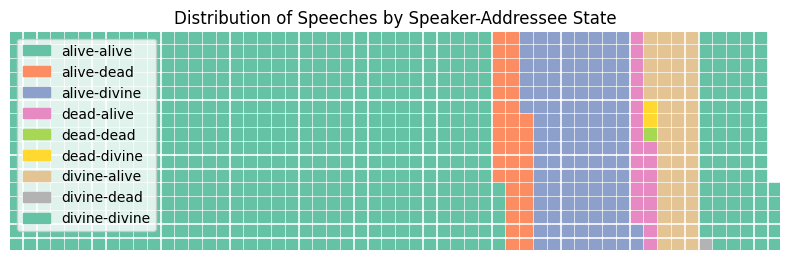

In [7]:
# data
labels, vals = zip(*[(k, len(v)) for k, v in index.items()])

# plot
fig = plt.figure(
    FigureClass=Waffle,
    rows=16,
    values=vals,
    labels=labels,
    legend={'loc': 'upper left', 'bbox_to_anchor': (0, 1)},
    figsize=(8, 6)
)
plt.title('Distribution of Speeches by Speaker-Addressee State')
plt.show()


Processing author: Silius


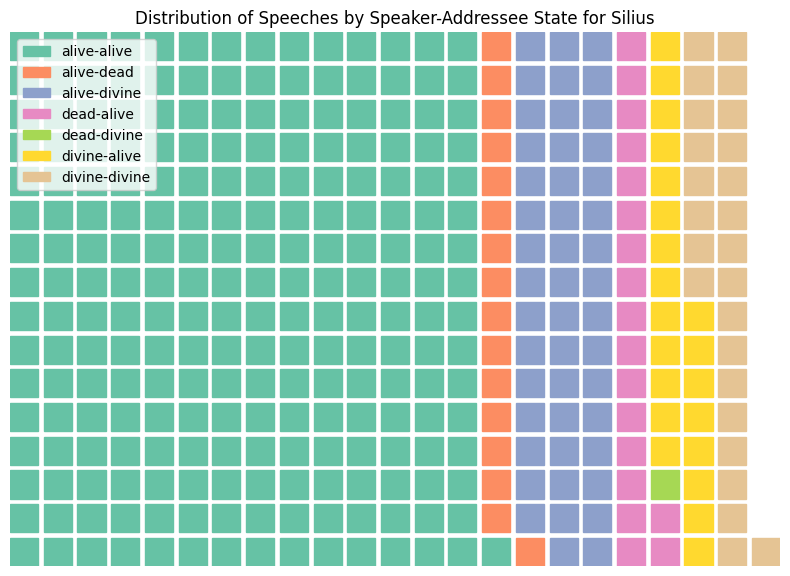


Processing author: Statius


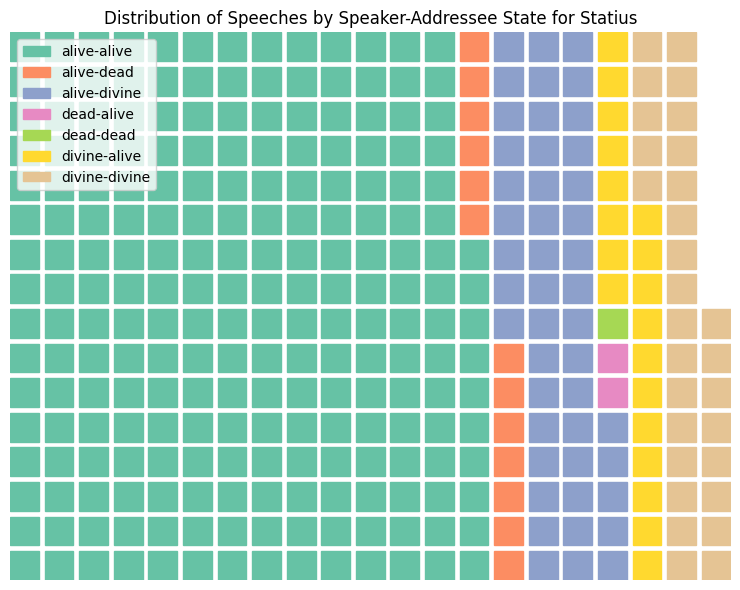


Processing author: Valerius Flaccus


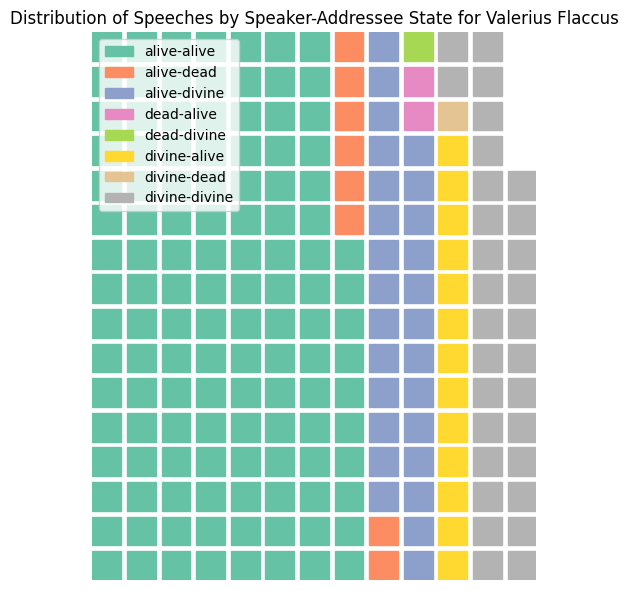

In [8]:
for author_name in sorted(list(authors_in_speeches)):
    print(f"\nProcessing author: {author_name}")
    # Filter speeches for the current author
    author_speeches = [s for s in speeches if s.author.name == author_name]

    # Create a dictionary for the current author's speeches where key is spkr-addr state combo, values are sets
    author_index = {
        "alive-alive": set(),
        "alive-dead": set(),
        "alive-divine": set(),
        "dead-alive": set(),
        "dead-dead": set(),
        "dead-divine": set(),
        "divine-alive": set(),
        "divine-dead": set(),
        "divine-divine": set(),
    }

    # Iterate over author's speeches
    for s in author_speeches:
        speaker_states_for_this_speech = set()
        for spkr in s.spkr:
            if spkr.being == "divine":
                speaker_states_for_this_speech.add("divine")
            elif spkr._attributes["changed"] == "death":
                speaker_states_for_this_speech.add("dead")
            else:
                speaker_states_for_this_speech.add("alive")

        addressee_states_for_this_speech = set()
        for addr in s.addr:
            if addr.being == "divine":
                addressee_states_for_this_speech.add("divine")
            elif addr._attributes["changed"] == "death":
                addressee_states_for_this_speech.add("dead")
            else:
                addressee_states_for_this_speech.add("alive")

        for spkr_state in speaker_states_for_this_speech:
            for addr_state in addressee_states_for_this_speech:
                # Only add if the key exists (to avoid KeyError for states that might not be in the initial index)
                if f"{spkr_state}-{addr_state}" in author_index:
                    author_index[f"{spkr_state}-{addr_state}"].add(s)

    # Filter out empty categories for the current author
    labels_author = []
    vals_author = []
    for k, v in author_index.items():
        if len(v) > 0:
            labels_author.append(k)
            vals_author.append(len(v))

    if not vals_author:
        print(f"No speeches with defined speaker-addressee states for {author_name}. Skipping waffle chart.")
        continue

    # plot
    fig = plt.figure(
        FigureClass=Waffle,
        rows=16, # Keeping rows consistent with the previous plot
        values=vals_author,
        labels=labels_author,
        legend={'loc': 'upper left', 'bbox_to_anchor': (0, 1)},
        figsize=(8, 6)
    )
    plt.title(f'Distribution of Speeches by Speaker-Addressee State for {author_name}')
    plt.show()

In [9]:
# just counts
for k, v in index.items():
    print(f"{k}: {len(v)}")

alive-alive: 565
alive-dead: 37
alive-divine: 120
dead-alive: 22
dead-dead: 1
dead-divine: 2
divine-alive: 53
divine-dead: 1
divine-divine: 84


In [10]:
# list individual speeches for dead people
print()
print()
for k, v in index.items():
    if "dead" in k:
        print(f"{k}:")
        for s in sorted(v):
            print(f"\t{s.work.title} {s.l_range}: {s.getSpkrString()} -> {s.getAddrString()}")



alive-dead:
	Punica 1.106-1.119: Hamilcar -> Hannibal, dead Dido
	Punica 5.588-5.591: Hannibal -> Carthaginians, dead Sychaeus
	Punica 5.594-5.602: Hannibal -> dead Sychaeus
	Punica 10.572-10.575: Hannibal -> dead L. Aemilius Paullus
	Punica 13.450-13.456: Publius Cornelius Scipio Africanus -> ghost of Appius Claudius Pulcher (consul 212)
	Punica 13.517-13.522: Publius Cornelius Scipio Africanus -> ghost of Sibyl
	Punica 13.623-13.627: Publius Cornelius Scipio Africanus -> ghost of Pomponia
	Punica 13.654-13.660: Publius Cornelius Scipio Africanus -> ghost of Gnaeus Cornelius Scipio Calvus, ghost of Publius Cornelius Scipio the Elder
	Punica 13.697-13.702: Publius Cornelius Scipio Africanus -> ghost of Gnaeus Cornelius Scipio Calvus, ghost of Publius Cornelius Scipio the Elder, gods
	Punica 13.711-13.715: Publius Cornelius Scipio Africanus -> ghost of L. Aemilius Paullus
	Punica 13.738-13.743: Publius Cornelius Scipio Africanus -> ghost of Hamilcar
	Punica 13.767-13.771: Publius Corn